# Setup to the CMUX Architecture Evaluation Scheduler

In [ ]:
import numpy as np
class LFSR:
  N: int
  K: int
  def __init__(self, samples: int, channels: int):
    self.N = samples
    self.K = channels

  def _prbs(self, N, taps=(2**3 - 1,1), seed=1):
    """
    Generate PRBS of length N using LFSR.
    taps: feedback taps (maximal length for chosen register)
    seed: initial state (integer, must be non-zero)
    """
    # Register size from largest tap
    m = max(taps)
    state = seed & ((1 << m) - 1)  # mask to m bits
    seq = []

    for _ in range(N):
        seq.append(state & 1)  # output = LSB
        # compute feedback bit (XOR of tap positions)
        feedback = 0
        for t in taps:
            feedback ^= (state >> (t-1)) & 1
        state = (state >> 1) | (feedback << (m-1))
    return np.array(seq)

  def _prbs_multichannel(self, taps=(7,1), seed=1):
    """
    Generate PRBS sequence of length N for K channels,
    each delayed by 1 sample w.r.t the previous one.
    """
    N = self.N
    K = self.K
    base = self._prbs(N + K, taps=taps, seed=seed)  # make longer so shifts are valid
    channels = np.vstack([np.roll(base, -k) for k in range(K)]) # create k channels by delaying for k samples the original seq

    return channels

  def __call__(self, taps=(7,1), seed=1):
    return self._prbs_multichannel(taps=taps, seed=seed)


In [ ]:
!pip install torch pytorch_lightning pylops tensorly scikit-learn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset
from pytorch_lightning.callbacks import EarlyStopping
from scipy.signal import fftconvolve
from collections import defaultdict

In [ ]:
N = 2**10
K = 2**3
P = LFSR(N, K)(taps=(7,2)).T
P = P[K:, :]*2 - 1
print(P.shape)
np.all((P.T @ P)  == np.eye(K))

(1024, 8)


np.False_

In [ ]:
np.dot(P.T, P), np.dot(P[:, 1] , P[:, 1])

(array([[1024, 1022, 1022, 1022, 1022, 1022, 1022, 1022],
        [1022, 1024, 1020, 1020, 1020, 1020, 1020, 1020],
        [1022, 1020, 1024, 1020, 1020, 1020, 1020, 1020],
        [1022, 1020, 1020, 1024, 1020, 1020, 1020, 1020],
        [1022, 1020, 1020, 1020, 1024, 1020, 1020, 1020],
        [1022, 1020, 1020, 1020, 1020, 1024, 1020, 1020],
        [1022, 1020, 1020, 1020, 1020, 1020, 1024, 1020],
        [1022, 1020, 1020, 1020, 1020, 1020, 1020, 1024]]),
 np.int64(1024))

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
class CMUXReconstructorV2(pl.LightningModule):
    def __init__(self, Y, PhiPsi, M0, lam=1e-5):
        super().__init__()
        # --- buffers: not optimized, but moved to device automatically ---
        self.register_buffer("PhiPsi", torch.from_numpy(PhiPsi).float())
        self.register_buffer("Y",      torch.from_numpy(Y).float())
        
        #self.Y      = torch.from_numpy(Y).float()
        #self.PhiPsi = torch.from_numpy(PhiPsi).float()
        #    --- learnable variable ---
        self.M      = nn.Parameter(torch.from_numpy(M0).float())
        self.lam    = lam

        # Lipschitz constant L = ||PhiPsi||² for ISTA step size
        self._L  = torch.linalg.norm(
            torch.from_numpy(PhiPsi).float(), ord=2
        ).item() ** 2

        self.training_losses = defaultdict(list)

    # ------------------------------------------------------------------
    # forward
    # ------------------------------------------------------------------
    def forward(self):
        return self.PhiPsi @ self.M

    # ------------------------------------------------------------------
    # ISTA proximal step — applied after each gradient update
    # ------------------------------------------------------------------
    def _soft_threshold(self):
        """Proximal operator for L1: shrink M toward zero by lam/L."""
        with torch.no_grad():
            tau = self.lam / self._L
            self.M.copy_(
                torch.sign(self.M) * torch.clamp(self.M.abs() - tau, min=0.0)
            )

    # ------------------------------------------------------------------
    # training
    # ------------------------------------------------------------------
    def training_step(self, batch, batch_idx):
        Y_hat = self()
        # smooth data-fidelity term only — L1 handled by proximal step
        loss  = 0.5 * torch.norm(Y_hat - self.Y, p="fro") ** 2

        # full LASSO objective for logging
        lasso_loss = loss + self.lam * self.M.abs().sum()
        self.training_losses["loss"].append(lasso_loss.item())
        self.log("loss", lasso_loss, prog_bar=True)
        return loss

    def on_after_backward(self):
        """Apply proximal operator after every gradient step."""
        self._soft_threshold()

    # ------------------------------------------------------------------
    # optimizer — Adam for the smooth term, proximal handles L1
    # ------------------------------------------------------------------
    def configure_optimizers(self):
        optimizer = torch.optim.SGD(
            self.parameters(),
            lr=1.0 / self._L,       # theoretically grounded: 1/Lipschitz
            momentum=0.9,
            nesterov=True,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=200,
            eta_min=1e-8,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "loss",
            },
        }

    # ------------------------------------------------------------------
    # dummy dataloader to satisfy Lightning
    # ------------------------------------------------------------------
    def train_dataloader(self):
        return DataLoader(TensorDataset(torch.zeros(1)), batch_size=1)

    # ------------------------------------------------------------------
    # run
    # ------------------------------------------------------------------
    def run(self, lam=None, epochs=300):
        if lam is not None:
            self.lam = lam

        early_stop = EarlyStopping(
            monitor="loss",
            min_delta=1e-8,
            patience=150,
            mode="min",
            stopping_threshold=self.lam,
        )
        trainer = pl.Trainer(
            max_epochs=epochs,
            enable_model_summary=False,
            enable_progress_bar=True,
            callbacks=[early_stop],
        )
        trainer.fit(self)
        return self.M.detach().cpu().numpy()

In [ ]:
class CMUXCompressor:
  """
    CMUX sampler with the introduction of a non-binary weight multiplier
  """
  names = {'fs', 'fclk', 'compression', 'seed', 'sample_moments', 'initial_index', 'A'}
  def __init__(self, fclk: float = 1.0, compression: float = 1, seed: float = 1234, zero_prob=0.95):
    self.fclk = fclk
    self.compression = compression
    self.fs = fclk
    self.seed = seed
    self.sample_moments = None
    self.A = None

  def multiplex(self, RF, t, compressed=False): # obtain the samples of each original channel
    # sample
    dt = np.diff(t[:2])[0]
    sub_sampling_factor = int(np.ceil(1/self.fclk / dt))
    tt = t[::sub_sampling_factor]
    RFs = RF[::sub_sampling_factor, :]
    output_channels = int(RFs.shape[-1]/self.compression)
    assert RFs.shape[-1]%self.compression == 0, "All compression level must be a multiple of the number of channels"
    #self.sample_moments = np.random.randn(*RFs.shape)
    #mask = self.sample_moments>0
    #self.sample_moments[mask] = 1
    #self.sample_moments[~mask] = -1
    self.sample_moments = LFSR(RFs.shape[0], RFs.shape[-1])(taps=(7,1), seed=self.seed)
    self.sample_moments = 2*self.sample_moments - 1
    self.sample_moments = self.sample_moments.T
    self.sample_moments = self.sample_moments[:RFs.shape[0], :]
    self.A = np.zeros((RFs.shape[-1], output_channels))
    for i in range(output_channels):
      self.A[i*self.compression:(i+1)*self.compression, i] = 1
    if compressed:
      return (self.sample_moments * RFs) @ self.A, tt
    return self.sample_moments * RFs, tt
  
  def demultiplex(self, Y, fc = 2e6, bw=0.7, epsilon = 1e-5, niters=200):
    from scipy.sparse import lil_matrix, csr_matrix
    from scipy.signal import gausspulse
    #from pylops.optimization.sparsity import fista
    from pylops.optimization.leastsquares import regularized_inversion
    from pylops.optimization.basic import cgls
    from pylops import MatrixMult
    #import cvxpy as cp
    N, nchannels = self.sample_moments.shape
    t = np.arange(-int(np.floor(0.5*N)), int(np.ceil(0.5*N))) / self.fclk
    t = t[:N]
    basis_function = gausspulse(t, fc=fc, bw=bw, bwr=-6, tpr=-60)
    Vpe = lil_matrix((N, N))  # lil is efficient for incremental construction
    for i in range(N):
        shifted = shift(basis_function, i - int(N/2), cval=0.0)
        nonzero_idx = shifted.nonzero()[0]
        Vpe[nonzero_idx, i] = shifted[nonzero_idx]
    Vpe = csr_matrix(Vpe)
    Vpe = Vpe.T
    #Phi = [np.diag(self.sample_moments[:, j]) for j in range(J)]  # list of (W x W)
    #G   = [Phi[j] @ Vpe for j in range(J)]
    X_hat = []
    nbatches = self.A.shape[1]
    batch_size = int(nchannels / nbatches)
    lambda_reg = epsilon * np.sqrt(np.log(N))
    for batch in tqdm.tqdm(range(nbatches)):
      PhiPsi = csr_matrix(np.hstack([
        np.diag(self.sample_moments[:, batch*batch_size + j]) \
          @ Vpe for j in range(batch_size)
      ]))
      # warm_start
      M_warm_start = PhiPsi.T @ Y[:, batch] # increase convergeance speed by providing warm start
      # build pylops operator
      Op = MatrixMult(PhiPsi, dtype=np.float32)
      x_res, *res = regularized_inversion(
        Op, 
        Y[:, batch],
        [], 
        x0=M_warm_start,
        **dict(
            #damp=lambda_reg,    # L2 regularization (Tikhonov): min ||Ax-y||² + λ||x||²
            iter_lim=350,
            show=True,
            atol=1e-8,
            btol=1e-8
        ))
      
      #x_res, *res = cgls(Op, Y[:, batch], x0 = M_warm_start, niter=300, tol=1e-8, show=True)
      print(f'Results = {res}')
      #cdemux = CMUXReconstructorV2(
      #  Y[:, batch], PhiPsi, M_warm_start/np.max(np.abs(M_warm_start)), lam=lambda_reg)
      #cdemux.run(lambda_reg)
      #print('Loss = ', cdemux.training_losses['loss'][-1])
      #plt.plot(np.log10(cdemux.training_losses['loss'])); plt.show()
      #x_res = cdemux.M.detach().numpy().\
      #  reshape((N, batch_size), order='F').astype(float)
      #X_hat.append(x_res.copy())
      X_hat.append(x_res.reshape((N, batch_size), order='F').copy())
    #X_hat.append(M_warm_start.reshape((N, batch_size), order='F'))
    return Vpe.toarray() @ np.real(np.hstack(X_hat)), None

    
"""
  def demultiplex(self, Y, fc = 2e6, bw=0.7, epsilon = 1e-6, niters=200):
    LS-F: least-squares in the Fourier domain (eq. 2 in paper).
    Exploits bandlimited structure — solves for M_hat in frequency domain.
    import cvxpy as cp
    from scipy.sparse import lil_matrix, csr_matrix
    from scipy.signal import gausspulse
    N = Y.shape[0]
    t = np.arange(-int(np.floor(0.5*N)), int(np.ceil(0.5*N))) / self.fclk
    t = t[:N]
    basis_function = gausspulse(t, fc=fc, bw=bw, bwr=-6, tpr=-60)
    Vpe = lil_matrix((N, N))  # lil is efficient for incremental construction
    for i in range(N):
        shifted = shift(basis_function, i - int(N/2), cval=0.0)
        nonzero_idx = shifted.nonzero()[0]
        Vpe[nonzero_idx, i] = shifted[nonzero_idx]
    Vpe = csr_matrix(Vpe)
    # --- build frequency index set Jd (eq. in Section II-B) ---
    lambda_reg = epsilon * np.sqrt(np.log(N))
    M0 = np.zeros_like(self.sample_moments)
    # build P matrix to perform trivial reconstruction, according to "The compressive multiplexer for multi-channel compressive sensing" - https://ieeexplore.ieee.org/document/5947224
    yy = Y @ self.A.T
    for ch in range(M0.shape[-1]):
      Pch = np.multiply(self.sample_moments[:,ch],np.eye(M0.shape[0]))
      M0[:, ch] = Pch @ yy[:,ch]
      M0[:, ch][ np.abs(M0[:, ch]) < lambda_reg ] = 0.0
    #Pt = torch.from_numpy(self.sample_moments).float()
    #At = torch.from_numpy(self.A).float()
    #Yt = torch.from_numpy(Y/np.max(np.abs(Y))).float()
    #Vpet = torch.from_numpy(Vpe.toarray()).float()
    #M0t = torch.from_numpy(M0).float()
    #cdemux = CMUXReconstructor(Pt, At, Yt, Vpet, M0t, lam=lambda_reg)
    #res = cdemux.run(lambda_reg)
    #M = cdemux.M.detach().numpy()
    #M = M / np.max(np.abs(M))
    # --- reconstruct M from sparse frequency coefficients ---
    return  Vpe.toarray() @ M, res
  """

'\n  def demultiplex(self, Y, fc = 2e6, bw=0.7, epsilon = 1e-6, niters=200):\n    LS-F: least-squares in the Fourier domain (eq. 2 in paper).\n    Exploits bandlimited structure — solves for M_hat in frequency domain.\n    import cvxpy as cp\n    from scipy.sparse import lil_matrix, csr_matrix\n    from scipy.signal import gausspulse\n    N = Y.shape[0]\n    t = np.arange(-int(np.floor(0.5*N)), int(np.ceil(0.5*N))) / self.fclk\n    t = t[:N]\n    basis_function = gausspulse(t, fc=fc, bw=bw, bwr=-6, tpr=-60)\n    Vpe = lil_matrix((N, N))  # lil is efficient for incremental construction\n    for i in range(N):\n        shifted = shift(basis_function, i - int(N/2), cval=0.0)\n        nonzero_idx = shifted.nonzero()[0]\n        Vpe[nonzero_idx, i] = shifted[nonzero_idx]\n    Vpe = csr_matrix(Vpe)\n    # --- build frequency index set Jd (eq. in Section II-B) ---\n    lambda_reg = epsilon * np.sqrt(np.log(N))\n    M0 = np.zeros_like(self.sample_moments)\n    # build P matrix to perform trivi

**References**

Akasaka, T., Fujimoto, K., Yamamoto, T., Okada, T., Fushumi, Y., Yamamoto, A., Tanaka, T., & Togashi, K. (2016). Optimization of Regularization Parameters in Compressed Sensing of Magnetic Resonance Angiography: Can Statistical Image Metrics Mimic Radiologists' Perception? PLOS ONE, 11(1), e0146548. https://doi.org/10.1371/journal.pone.0146548 
Cited by: 52

Chamorro-Servent, J., Aguirre, J., Ripoll, J., Vaquero, J. J., & Desco, M. (2011). Feasibility of U-curve method to select the regularization parameter for fluorescence diffuse optical tomography in phantom and small animal studies. Optics Express, 19(12), 11490. https://doi.org/10.1364/oe.19.011490
Cited by: 48

Unpingco, J. (2016). Python for Probability, Statistics, and Machine Learning. Springer International Publishing. https://doi.org/10.1007/978-3-319-30717-6
Cited by: 156

Wu, F., & Rebeschini, P. (2022). Nearly minimax-optimal rates for noisy sparse phase retrieval via early-stopped mirror descent. Information and Inference: A Journal of the IMA, 12(2), 633–713. https://doi.org/10.1093/imaiai/iaac024
Cited by: 11

Note: The "Rule of Thumb" ($\lambda = \sigma \sqrt{2 \log n}$) and LASSO specific behaviors are standard results in high-dimensional statistics (Tibshirani, 1996).

### Finding optimal lambda parameter for a specific case

5it [00:07,  1.52s/it]


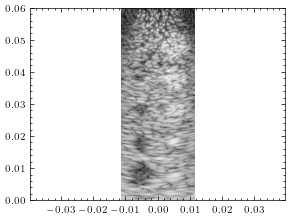

  0%|          | 0/1 [14:14<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
from copy import deepcopy
from scipy.ndimage import shift
from scipy.sparse import lil_matrix, csr_matrix
from scipy.signal import gausspulse

cmux_sweep_config = {
    'fs': np.array([80])*1e6,
    'k': np.array([20]),
    'lam': [1e-6],
}
f0_to_plot = [2.5e6]
#fig, ax = plt.subplots(4, 8, figsize=(10,10))

RUN_FS_SEARCH = False
if RUN_FS_SEARCH:
    current_iteration = 1
    for i,fclk in enumerate(cmux_sweep_config['fs']):
        # Build simulation media
        # Setup 2D array parameters:
        param = pymust.utils.Param()
        f0_plot = f0_to_plot[0]
        param.fc = f0_plot
        wavelength = c0 / f0_plot
        pitch = wavelength / 2
        param.kerf = KERF
        param.pitch = pitch
        param.width = pitch - param.kerf
        param.height = ROWS * pitch - param.kerf
        param.Nelements = COLUMNS
        param.bandwidth = 70
        param.radius = np.inf
        
        param.fs = fclk
        param.attenuation = 0.5
        
        # Setup the simulation medium
        dx = dy = dz = wavelength / 10
        Nx = int(Dx / dx) + 1 # Azimutal dir.
        Nz = int(Dy / dy) + 1 # Longitudinal dir.
        Ny = int(Dz / dz) + 1 # Elevational dir.

        x_extent = np.linspace(-Dx/2,Dx/2,Nx)
        z_extent = np.linspace(0,Dz,Nz)
        xi,zi = np.meshgrid(x_extent, z_extent);
        yi = np.zeros(xi.shape)
        
        fc = 10 * param.fc # 10 * Center Frequency at least
        xs,ys,zs,RC = pymust.genscat(np.array([Dz, Dz*1.5]),c0/param.fc)
        RC = 0.1 * RC
        
        # Setup scatterer and hole location
        
        # draw increasing hole scatterers
        startx = -MAX_DIAMETER
        centerx = np.array([-MAX_DIAMETER/1.5, MAX_DIAMETER/1.5])
        startz = MAX_DIAMETER * 1.5
        centerz = np.linspace(startz, startz + NUM_SCATTER * (MAX_DIAMETER), NUM_SCATTER)
        diameters = np.linspace(MIN_DIAMETER, MAX_DIAMETER, NUM_SCATTER)

        for k, cz in enumerate(centerz):
            RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[0], cz), np.min(RC))

        for k, cz in enumerate(centerz[::-1]):
            RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[1], cz), np.max(RC))

        # region without echoes / reflectionless (blood vessels)
        anechoic_roi = np.zeros(xi.shape)

        # region with maximal echo / reflection (bones, nerves)
        hyperechoic_roi = np.zeros(xi.shape)

        for k, cz in enumerate(centerz):
            mask = (xi - centerx[0])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
            anechoic_roi[mask] = 1

        for k, cz in enumerate(centerz[::-1]):
            mask = (xi - centerx[1])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
            hyperechoic_roi[mask] = 1
        
        
        # Setup transmit events
        MAX_ANGLE = 15.0 # 10.0
        MIN_ANGLE = -15.0 # -10.0
        NUM_PLANAR_WAVES = 5
        tilt = np.linspace(MIN_ANGLE,MAX_ANGLE,NUM_PLANAR_WAVES)/180*np.pi; # tilt angles in rad
        #tilt = [MIN_ANGLE, 0.0, MAX_ANGLE]
        width = 15/180*np.pi # Diverging wave width with 30 degrees
        txdel = []
        for t in tilt:
            txdel.append(pymust.txdelay(param, t, width))
        txdel_planar = np.array(txdel)
        
        # Re-simulate RF channels
        RF = [0]*len(txdel_planar)
        for k, transmit_event in tqdm.tqdm(enumerate(txdel_planar)):
        RF[k], _ = pymust.simus(xs,zs,RC,txdel_planar[k], param)
        RF[k] = RF[k] / np.max(np.abs(RF[k]))
        
        afe_cfg = AFEConfig()
        afe = AFE(param, afe_cfg)
        
        RF_tgc = []
        for r in RF:
        #RF_tgc.append(np.clip(afe(r), -1.0, 1.0))
        RF_tgc.append(afe(r))
        IQ = []
        for r in RF_tgc:
        IQ.append(pymust.rf2iq(
            r,param.fs,param.fc))
        bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
        for k, t in enumerate(txdel_planar):
            param.TXdelay = t
            bIQ[:,:,k] = (pymust.dasmtx(
            IQ[k], xi,zi, param) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
        cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
        I = pymust.bmode(cIQ,60); #log-compressed image
        plt.imshow(I, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
        plt.axis('equal')
        plt.show()
        param_cpy = deepcopy(param)
        imq_evaluator = ImageMetricEvaluator(I, anechoic_roi, hyperechoic_roi)
        for j,comp_ch in enumerate(cmux_sweep_config['k']):
            for lam in tqdm.tqdm(cmux_sweep_config['lam']):
                afe_cfg = AFEConfig()
                afe = AFE(param, afe_cfg)
                cmux = CMUXCompressor(fclk=fclk, compression=comp_ch, zero_prob=0)
                #tgc_settings = np.linspace(0.0, afe_cfg.gain_range, num=afe_cfg.gain_steps)
                RF_tgc = []
                for r in RF:
                #RF_tgc.append(np.clip(afe(r), -1.0, 1.0))
                    RF_tgc.append(afe(r))
                
                # multiplex
                X_hat = []
                for r in RF_tgc:
                    t = np.arange(0, r.shape[0])/param.fs
                    Y, _ = cmux.multiplex(r, t, compressed=True)
                    X_hat.append(cmux.demultiplex(Y/np.max(np.abs(Y)), fc=param.fc, bw=param.bandwidth/100, epsilon=1e-6)[0])
                
                IQ = []
                for r in X_hat:
                    IQ.append(pymust.rf2iq(r,fclk,param.fc))
                bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
                param_cpy.fs = fclk
                for k, t in enumerate(txdel_planar):
                    param.TXdelay = t
                    bIQ[:,:,k] = (pymust.dasmtx(IQ[k], xi,zi, param_cpy) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
                cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
                Imeas = pymust.bmode(cIQ,60); #log-compressed image
                if current_iteration % 1 == 0:
                    plt.imshow(Imeas, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
                    plt.axis('equal')
                    plt.show()
                #ax[j,i + n*4].imshow(I, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
                #ax[j,i].set_axis('equal')
                #ax[j, i + n*4].set_yticks([])
                #ax[j, i + n*4].set_xticks([])
                results_img_eval_raw = imq_evaluator.evaluate(Imeas)
                results_img_eval = {k:v for k,v in results_img_eval_raw.items() if k != "gcnr"}
                results_img_eval['a-gcnr'], results_img_eval['h-gcnr'] = results_img_eval_raw['gcnr']
                results_db_row = {'f0_mhz': f0_plot/1e6, 'fs_mhz': fclk/1e6, 'ch_compression': comp_ch, 'lam':lam}
                #results_db_row.update(afe_cfg.default())
                results_db_row.update(results_img_eval)
                print(results_db_row)
                if current_iteration == 1:
                    with open(dir / 'mc_results_cmux_afe_fs_search.csv', 'a') as fp:
                        fp.write(','.join([k for k in results_db_row.keys()])+'\n')
                #print(results_db_row)
                with open(dir / 'mc_results_cmux_afe_fs_search.csv', 'a') as fp:
                    fp.write(','.join([str(k) for k in results_db_row.values()])+'\n')
                current_iteration += 1
#fig.tight_layout()
#fig.savefig(dir/'comparison_monte_carlo.pdf', dpi=300)

In [ ]:
IQ = []
for r in X_hat:
    shape = r.shape
    x = r.reshape(-1, order='F').reshape(shape)
    IQ.append(pymust.rf2iq(r,fclk,param.fc))
bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
param_cpy.fs = fclk
for k, t in enumerate(txdel_planar):
    param.TXdelay = t
    bIQ[:,:,k] = (pymust.dasmtx(IQ[k], xi,zi, param_cpy) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
Imeas = pymust.bmode(cIQ,60); #log-compressed image
if current_iteration % 1 == 0:
    plt.imshow(Imeas, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
    plt.axis('equal')
    plt.show()

In [ ]:
X_hat[0].shape, X_hat[0].dtype

In [ ]:
plt.plot(X_hat[1])

In [ ]:
df = pd.read_csv(dir / 'mc_results_cmux_afe_fs_search.csv')
df.head()

In [ ]:
yvars = df.columns[-3:]

fig, ax = plt.subplots(1,len(yvars), figsize=(6.3,2))

[sns.lineplot(data=df, x='fs_mhz', y=yvar, legend=True, palette='colorblind', hue='ch_compression',marker='s',markersize=5, ax=ax[k]) for k, yvar in enumerate(yvars)]
for i, axis in enumerate(ax):
    axis.set_ylabel(yvars[i].upper())
    axis.set_xlabel('Sampling Frequency \n$F_S$ (MHz)')
    #axis.set_yscale('log')
    #axis.set_yticks([1e-2, 1e-1, 3e-1])
fig.tight_layout()
fig.savefig(dir / 'cmux_fs_parameter_search.pdf', dpi=300)


In [ ]:
lamdf = pd.read_csv(dir / 'mc_results_cmux_afe_lambda_search.csv')
lamdf.head()

In [ ]:
yvars = lamdf.columns[-3:]

fig, ax = plt.subplots(1,len(yvars), figsize=(6.3,2))

[sns.lineplot(data=lamdf[lamdf['f0_mhz']==2.0][lamdf['ch_compression']!=40], x='lam', y=yvar, legend=False, palette='colorblind', hue='ch_compression',marker='s',errorbar=None,markersize=5, ax=ax[k]) for k, yvar in enumerate(yvars)]

for i, axis in enumerate(ax):
    axis.set_ylabel(yvars[i].upper())
    axis.set_xlabel('L1 Regularization \nParameter $\lambda$')
    axis.set_xscale('log')
    #axis.set_yscale('log')
    #axis.set_yticks([1e-2, 1e-1, 3e-1])
fig.tight_layout()
fig.savefig(dir / 'cmux_l1_reg_parameter_search.pdf', dpi=300)

In [ ]:
from copy import deepcopy
cmux_sweep_config = {
    'fs': np.array([25, 50, 75, 100, 125, 150, 210])*1e6,
    'k': np.array([2, 5, 10, 20, 40]),
}
f0_to_plot = [2.0e6, 2.5e6, 4.0e6, 6.0e6]
#fig, ax = plt.subplots(4, 8, figsize=(10,10))

current_iteration = 1
for n, f0_plot in enumerate(f0_to_plot):
    # Build simulation media
    # Setup 2D array parameters:
    param = pymust.utils.Param()
    param.fc = f0_plot
    wavelength = c0 / f0_plot
    pitch = wavelength / 2
    param.kerf = KERF
    param.pitch = pitch
    param.width = pitch - param.kerf
    param.height = ROWS * pitch - param.kerf
    param.Nelements = COLUMNS
    param.bandwidth = 70
    param.radius = np.inf
    
    param.fs = np.max(cmux_sweep_config['fs'])
    param.attenuation = 0.5
    
    # Setup the simulation medium
    dx = dy = dz = wavelength / 10
    Nx = int(Dx / dx) + 1 # Azimutal dir.
    Nz = int(Dy / dy) + 1 # Longitudinal dir.
    Ny = int(Dz / dz) + 1 # Elevational dir.

    x_extent = np.linspace(-Dx/2,Dx/2,Nx)
    z_extent = np.linspace(0,Dz,Nz)
    xi,zi = np.meshgrid(x_extent, z_extent);
    yi = np.zeros(xi.shape)
    
    fc = 10 * param.fc # 10 * Center Frequency at least
    xs,ys,zs,RC = pymust.genscat(np.array([Dz, Dz*1.5]),c0/param.fc)
    RC = 0.1 * RC
    
    # Setup scatterer and hole location
    
    # draw increasing hole scatterers
    startx = -MAX_DIAMETER
    centerx = np.array([-MAX_DIAMETER/1.5, MAX_DIAMETER/1.5])
    startz = MAX_DIAMETER * 1.5
    centerz = np.linspace(startz, startz + NUM_SCATTER * (MAX_DIAMETER), NUM_SCATTER)
    diameters = np.linspace(MIN_DIAMETER, MAX_DIAMETER, NUM_SCATTER)

    for k, cz in enumerate(centerz):
        RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[0], cz), np.min(RC))

    for k, cz in enumerate(centerz[::-1]):
        RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[1], cz), np.max(RC))

    # region without echoes / reflectionless (blood vessels)
    anechoic_roi = np.zeros(xi.shape)

    # region with maximal echo / reflection (bones, nerves)
    hyperechoic_roi = np.zeros(xi.shape)

    for k, cz in enumerate(centerz):
        mask = (xi - centerx[0])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
        anechoic_roi[mask] = 1

    for k, cz in enumerate(centerz[::-1]):
        mask = (xi - centerx[1])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
        hyperechoic_roi[mask] = 1
    
    
    # Setup transmit events
    MAX_ANGLE = 15.0 # 10.0
    MIN_ANGLE = -15.0 # -10.0
    NUM_PLANAR_WAVES = 5
    tilt = np.linspace(MIN_ANGLE,MAX_ANGLE,NUM_PLANAR_WAVES)/180*np.pi; # tilt angles in rad
    #tilt = [MIN_ANGLE, 0.0, MAX_ANGLE]
    width = 15/180*np.pi # Diverging wave width with 30 degrees
    txdel = []
    for t in tilt:
        txdel.append(pymust.txdelay(param, t, width))
    txdel_planar = np.array(txdel)
    
    # Re-simulate RF channels
    RF = [0]*len(txdel_planar)
    for k, transmit_event in tqdm.tqdm(enumerate(txdel_planar)):
      RF[k], _ = pymust.simus(xs,zs,RC,txdel_planar[k], param)
      RF[k] = RF[k] / np.max(np.abs(RF[k]))
    
    afe_cfg = AFEConfig()
    afe = AFE(param, afe_cfg)
    
    RF_tgc = []
    for r in RF:
      #RF_tgc.append(np.clip(afe(r), -1.0, 1.0))
      RF_tgc.append(afe(r))
    IQ = []
    for r in RF_tgc:
      IQ.append(pymust.rf2iq(
        r,param.fs,param.fc))
    bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
    for k, t in enumerate(txdel_planar):
        param.TXdelay = t
        bIQ[:,:,k] = (pymust.dasmtx(
          IQ[k], xi,zi, param) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
    cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
    I = pymust.bmode(cIQ,60); #log-compressed image
    plt.imshow(I, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
    plt.axis('equal')
    plt.show()
    param_cpy = deepcopy(param)
    imq_evaluator = ImageMetricEvaluator(I, anechoic_roi, hyperechoic_roi)
    for i,fclk in tqdm.tqdm(enumerate(cmux_sweep_config['fs'])):
        for j,comp_ch in enumerate(cmux_sweep_config['k']):
            afe_cfg = AFEConfig()
            afe = AFE(param, afe_cfg)
            cmux = CMUXCompressor(fclk=fclk, compression=comp_ch, zero_prob=0)
            #tgc_settings = np.linspace(0.0, afe_cfg.gain_range, num=afe_cfg.gain_steps)
            RF_tgc = []
            for r in RF:
              #RF_tgc.append(np.clip(afe(r), -1.0, 1.0))
              RF_tgc.append(afe(r))
              
            # multiplex
            X_hat = []
            for r in RF_tgc:
              t = np.arange(0, r.shape[0])/param.fs
              Y, _ = cmux.multiplex(r, t, compressed=True)
              X_hat.append(cmux.demultiplex(Y, fc=param.fc, bw=param.bandwidth/100)[0])
            
            
            IQ = []
            for r in X_hat:
              IQ.append(pymust.rf2iq(r,fclk,param.fc))
            bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
            param_cpy.fs = fclk
            for k, t in enumerate(txdel_planar):
                param.TXdelay = t
                bIQ[:,:,k] = (pymust.dasmtx(
                  IQ[k], xi,zi, param_cpy) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
            cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
            Imeas = pymust.bmode(cIQ,60); #log-compressed image
            if current_iteration % 2 == 0:
              plt.imshow(Imeas, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
              plt.axis('equal')
              plt.show()
            #ax[j,i + n*4].imshow(I, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
            #ax[j,i].set_axis('equal')
            #ax[j, i + n*4].set_yticks([])
            #ax[j, i + n*4].set_xticks([])
            results_img_eval_raw = imq_evaluator.evaluate(Imeas)
            results_img_eval = {k:v for k,v in results_img_eval_raw.items() if k != "gcnr"}
            results_img_eval['a-gcnr'], results_img_eval['h-gcnr'] = results_img_eval_raw['gcnr']
            results_db_row = {'f0_mhz': f0_plot/1e6, 'fs_mhz': fclk/1e6, 'ch_compression': comp_ch}
            #results_db_row.update(afe_cfg.default())
            results_db_row.update(results_img_eval)
            print(results_db_row)
            if current_iteration == 1:
              with open(dir / 'mc_results_cmux_afe_eval.csv', 'a') as fp:
                fp.write(','.join([k for k in results_db_row.keys()])+'\n')
            #print(results_db_row)
            with open(dir / 'mc_results_cmux_afe_eval.csv', 'a') as fp:
              fp.write(','.join([str(k) for k in results_db_row.values()])+'\n')
            current_iteration += 1
            
#fig.tight_layout()
#fig.savefig(dir/'comparison_monte_carlo.pdf', dpi=300)

## CMUX Architecture Monte Carlo Results Evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
plt.style.use(['science', 'nature'])

In [3]:
cmux_eval_df = pd.read_csv('./cmux_eval_vs_fs.csv')
cmux_eval_df.head()

,f0_mhz,fs_mhz,ch_compression,lam,mse,psnr,ssim,a-gcnr,h-gcnr
0,2.5,50.0,10,0.000001,626.050788,20.164708,0.851570,0.251130,0.130009
1,2.5,50.0,20,0.000001,1282.626290,17.049802,0.470896,0.227854,0.081927
2,2.5,50.0,40,0.000001,1797.240953,15.584741,0.260287,0.200702,0.163186
3,2.5,80.0,10,0.000001,49.944391,31.145936,0.999616,0.237936,0.134781
4,2.5,80.0,20,0.000001,861.795164,18.776763,0.654852,0.222495,0.079711


In [4]:
xvar = cmux_eval_df.columns[1]
xvar

'fs_mhz'

In [5]:
yvars = list(cmux_eval_df.columns[4:7])
yvars

['mse', 'psnr', 'ssim']

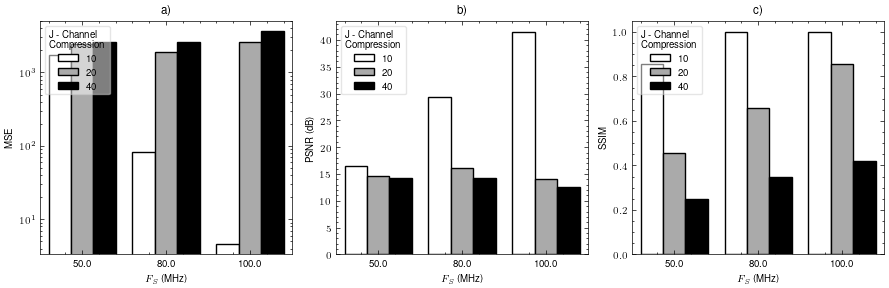

In [60]:
fig, ax = plt.subplots(1,len(yvars), figsize=(9,3))
letters = [c for c in range(ord('a'),ord('z')+1)]
for i, yvar in enumerate(yvars):
    sns.barplot(
        data=cmux_eval_df, x='fs_mhz', y=yvar, ax=ax[i], hue='ch_compression',legend=True, edgecolor='black', palette='gist_yarg', errorbar=None)
    if yvar not in ['ssim', 'psnr']:
        ax[i].set_yscale('log')
    ax[i].set_xlabel('$F_S$ (MHz)')
    yvarname = yvar.upper()+' (dB)' if yvar=='psnr' else yvar.upper()
    ax[i].set_ylabel(yvarname)
    ax[i].legend(title='J - Channel\nCompression',loc='upper left', frameon=True, edgecolor=None, facecolor='white', framealpha=0.5)
    ax[i].set_title(chr(letters[i]) + ')')
fig.tight_layout()
fig.savefig('./cmux_eval_vs_fs.pdf', dpi=300)

## B-mode & Color Doppler Img. Quality vs. Charge-Sharing CMUX Non-Idealities Evaluation

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scienceplots
plt.style.use(['science', 'nature'])

In [64]:
cs_cmux_eval_df = pd.read_csv('./mc_results_cs_cmux_nonideal.csv', dtype=np.float32, header=0)
cs_cmux_eval_color_doppler_df = pd.read_csv('./mc_results_cs_cmux_nonideal_color_doppler.csv', dtype=np.float32, header=0)
cs_cmux_eval_df['mode']='B-mode'; cs_cmux_eval_df['model'] = 'single-ended';
cs_cmux_eval_color_doppler_df['mode'] = 'Color-Doppler'; cs_cmux_eval_color_doppler_df['model'] = 'single-ended';

cs_cmux_eval_diff_df = pd.read_csv('./mc_results_matched_95_differential_cs_cmux_nonideal.csv', dtype=np.float32, header=0)
cs_cmux_eval_color_doppler_diff_df = pd.read_csv('./mc_results_matched_95_differential_cs_cmux_nonideal_color_doppler.csv', dtype=np.float32, header=0)
cs_cmux_eval_diff_df['mode']='B-mode'; cs_cmux_eval_diff_df['model'] = 'differential-matched95';
cs_cmux_eval_color_doppler_diff_df['mode'] = 'Color-Doppler'; cs_cmux_eval_color_doppler_diff_df['model'] = 'differential-matched95';

cs_cmux_eval_diff_matched_df = pd.read_csv('./mc_results_matched_70_differential_cs_cmux_nonideal.csv', dtype=np.float32, header=0)
cs_cmux_eval_color_doppler_diff_matched_df = pd.read_csv('./mc_results_matched_70_differential_cs_cmux_nonideal_color_doppler.csv', dtype=np.float32, header=0)
cs_cmux_eval_diff_matched_df['mode']='B-mode'; cs_cmux_eval_diff_matched_df['model'] = 'differential-matched70';
cs_cmux_eval_color_doppler_diff_matched_df['mode'] = 'Color-Doppler'; cs_cmux_eval_color_doppler_diff_matched_df['model'] = 'differential-matched70';

cs_cmux_eval_df = pd.concat([
    cs_cmux_eval_df, 
    cs_cmux_eval_color_doppler_df, 
    cs_cmux_eval_diff_df,
    cs_cmux_eval_color_doppler_diff_df,
    cs_cmux_eval_diff_matched_df,
    cs_cmux_eval_color_doppler_diff_matched_df
], ignore_index=True)

In [65]:
#cs_cmux_eval_df['gain_error_factor'] = cs_cmux_eval_df['gain_error_factor'].replace(np.inf, 100)
cs_cmux_eval_df = cs_cmux_eval_df.drop('gain_error_factor', axis=1)

In [66]:
cs_cmux_eval_df

,mse,psnr,ssim,a-gcnr,h-gcnr,cvar,jitter_factor,charge_injection_factor,clock_feedthrough_factor,f0_mhz,fs_mhz,ch_compression,mode,model
0,3743.437012,12.398098,0.850773,0.261893,0.048676,0.102594,0.0,0.0,0.0,2.5,50.0,10.0,B-mode,single-ended
1,3941.739746,12.173924,0.847047,0.276358,0.050472,0.094774,0.0,0.0,0.0,2.5,50.0,10.0,B-mode,single-ended
2,2753.084229,13.732609,0.851126,0.254894,0.093138,0.000298,0.0,0.0,0.0,2.5,50.0,10.0,B-mode,single-ended
3,2753.642334,13.731729,0.850953,0.255068,0.093748,-0.007627,0.0,0.0,0.0,2.5,50.0,10.0,B-mode,single-ended
4,2749.244385,13.738670,0.850921,0.254255,0.093287,-0.004874,0.0,0.0,0.0,2.5,50.0,10.0,B-mode,single-ended
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5641,6197.960938,10.208315,0.901811,NaN,NaN,0.000000,0.0,0.0,0.0,2.5,50.0,10.0,Color-Doppler,differential-matched70
5642,6195.725098,10.209883,0.901800,NaN,NaN,0.000000,0.0,0.0,0.0,2.5,50.0,10.0,Color-Doppler,differential-matched70
5643,6196.997559,10.208990,0.901790,NaN,NaN,0.000000,0.0,0.0,0.0,2.5,50.0,10.0,Color-Doppler,differential-matched70
5644,6200.213379,10.206738,0.901803,NaN,NaN,0.000000,0.0,0.0,0.0,2.5,50.0,10.0,Color-Doppler,differential-matched70


In [67]:
yvars = list(cs_cmux_eval_df.columns[:5])
xvars = list(cs_cmux_eval_df.columns[5:-2])

yvars, xvars

(['mse', 'psnr', 'ssim', 'a-gcnr', 'h-gcnr'],
 ['cvar',
  'jitter_factor',
  'charge_injection_factor',
  'clock_feedthrough_factor',
  'f0_mhz',
  'fs_mhz',
  'ch_compression'])

In [68]:
for xvar in xvars:
    cs_cmux_eval_df[xvar] = np.sqrt(cs_cmux_eval_df[xvar]**2)

In [69]:
batch_size = 5

# Average xvars within each (model, mode) group and batch
for xvar in xvars:
    print(xvar)
    cs_cmux_eval_df[xvar == 0] = 1e-3
    cs_cmux_eval_df['mean_' + xvar] = (
        cs_cmux_eval_df
        .groupby(
            [
                'model',
                'mode',
                cs_cmux_eval_df.groupby(['model', 'mode']).cumcount() // batch_size
            ]
        )[xvar]
        .transform('mean')
    )

cs_cmux_eval_df.head()

cvar
jitter_factor
charge_injection_factor
clock_feedthrough_factor
f0_mhz
fs_mhz
ch_compression


,mse,psnr,ssim,a-gcnr,h-gcnr,cvar,jitter_factor,charge_injection_factor,clock_feedthrough_factor,f0_mhz,...,mode,model,False,mean_cvar,mean_jitter_factor,mean_charge_injection_factor,mean_clock_feedthrough_factor,mean_f0_mhz,mean_fs_mhz,mean_ch_compression
0,3743.437012,12.398098,0.850773,0.261893,0.048676,0.102594,0.0,0.0,0.0,2.5,...,B-mode,single-ended,0.001,0.042033,0.0,0.0,0.0,2.5,50.0,10.0
1,3941.739746,12.173924,0.847047,0.276358,0.050472,0.094774,0.0,0.0,0.0,2.5,...,B-mode,single-ended,0.001,0.042033,0.0,0.0,0.0,2.5,50.0,10.0
2,2753.084229,13.732609,0.851126,0.254894,0.093138,0.000298,0.0,0.0,0.0,2.5,...,B-mode,single-ended,0.001,0.042033,0.0,0.0,0.0,2.5,50.0,10.0
3,2753.642334,13.731729,0.850953,0.255068,0.093748,0.007627,0.0,0.0,0.0,2.5,...,B-mode,single-ended,0.001,0.042033,0.0,0.0,0.0,2.5,50.0,10.0
4,2749.244385,13.738670,0.850921,0.254255,0.093287,0.004874,0.0,0.0,0.0,2.5,...,B-mode,single-ended,0.001,0.042033,0.0,0.0,0.0,2.5,50.0,10.0


In [70]:
from pathlib import Path
savedir = Path('./').resolve()
savedir

PosixPath('/Users/dasdias/Documents/PhD-NOVA/Writting/DataAndSOTA/us_uoc_afe_evaluation')

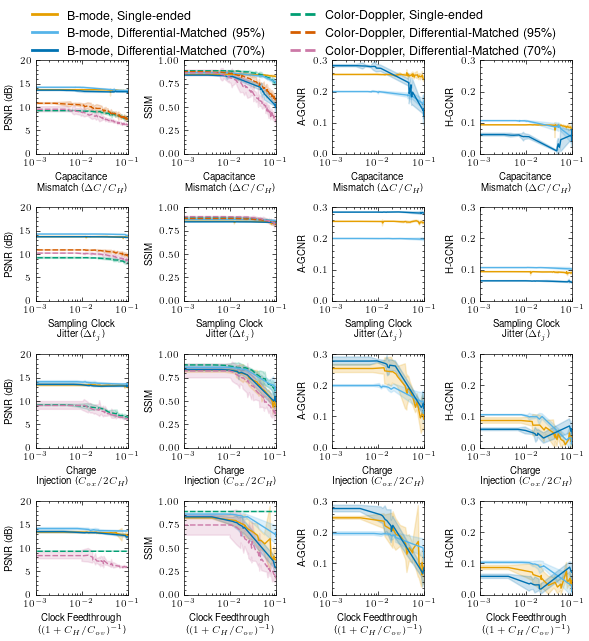

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import numpy as np

# Define custom colors for each model-mode combination
color_map = {
    ('B-mode', 'single-ended'): '#E69F00',          # Orange
    ('B-mode', 'differential-matched95'): '#56B4E9',          # Sky blue
    ('B-mode', 'differential-matched70'): '#0072B2',  # Blue

    ('Color-Doppler', 'single-ended'): '#009E73',          # Bluish green
    ('Color-Doppler', 'differential-matched95'): '#D55E00',          # Vermillion
    ('Color-Doppler', 'differential-matched70'): '#CC79A7',  # Purple
}

xvars_plot = xvars[0:4]
yvars_plot = yvars[1:5]

fig, ax = plt.subplots(len(xvars_plot), len(yvars_plot), figsize=(6,6))

labels = {
    'cvar': 'Capacitance\n Mismatch ($\Delta C / C_H$)',
    'jitter_factor': 'Sampling Clock\n Jitter ($\Delta t_j$)',
    'charge_injection_factor': 'Charge\n Injection ($C_{ox} / 2C_H$)',
    'clock_feedthrough_factor': 'Clock Feedthrough\n ($(1 + C_H / C_{ov})^{-1}$)'
}

for i, yvar in enumerate(yvars_plot):
    for j, xvar in enumerate(xvars_plot):

        data_filtered = cs_cmux_eval_df

        # Filter and create combined column
        #data_filtered = data[data[xvar] > 0.0].copy()
        data_filtered['mode_model'] = list(
            zip(data_filtered['mode'], data_filtered['model'])
        )

        sns.lineplot(
            data=data_filtered,
            x='mean_' + xvar,
            y=yvar,
            ax=ax[j, i],
            hue='mode_model',
            style='mode',
            legend=False,
            palette=color_map,
            estimator="mean",
            errorbar="sd"
        )
        if yvar == 'mse':
            ax[j, i].set_ylim(1e3, 1e5)
            ax[j, i].set_yscale('log')
        elif yvar == 'ssim':
            ax[j, i].set_ylim(0.0, 1.0)
        elif yvar == 'psnr':
            ax[j, i].set_ylim(0.0, 20)
        else:
            ax[j, i].set_ylim(0.0, 0.3)
        ax[j, i].set_xlim(1e-3,1e-1)

        #if xvar == 'cvar':
            #ax[j, i].set_xlim(0.0, 0.06)

        ax[j, i].set_ylabel(yvar.upper())

        if yvar == 'psnr':
            ax[j, i].set_ylabel(yvar.upper() + ' (dB)')

        ax[j, i].set_xlabel(labels[xvar])
        ax[j, i].set_xscale('log')
        #ax[j, i].set_xticks(1e-2 * np.linspace(0.0, 7.5, num=5))

# Create custom legend
legend_elements = [
    Line2D([0], [0], color='#E69F00', lw=2,
           label='B-mode, Single-ended'),

    Line2D([0], [0], color='#56B4E9', lw=2,
           label='B-mode, Differential-Matched (95\%)'),

    Line2D([0], [0], color='#0072B2', lw=2,
           label='B-mode, Differential-Matched (70\%)'),

    Line2D([0], [0], color='#009E73', lw=2, ls='--',
           label='Color-Doppler, Single-ended'),

    Line2D([0], [0], color='#D55E00', lw=2, ls='--',
           label='Color-Doppler, Differential-Matched (95\%)'),

    Line2D([0], [0], color='#CC79A7', lw=2, ls='--',
           label='Color-Doppler, Differential-Matched (70\%)'),
]

# Add legend at the top of the figure
fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 1.08),
    frameon=False,
    fontsize=9
)

fig.tight_layout()

fig.savefig(
    savedir / 'mc_cs_cmux_color_doppler_bmode_eval_results.pdf',
    dpi=1000,
    bbox_inches='tight'
)